In [4]:
# ==========================================
# Stage Master 1 Bioinformatique
# Analyse transcriptomique - Semaine 1
# ==========================================

# Bibliothèques principales
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Affichage dans Jupyter
%matplotlib inline

print("Toutes les bibliothèques sont chargées avec succès.")

Toutes les bibliothèques sont chargées avec succès.


In [3]:
print("Pandas :", pd.__version__)
print("Numpy :", np.__version__)
print("GEOparse :", GEOparse.__version__)

Pandas : 3.0.3
Numpy : 2.4.1
GEOparse : 2.0.4


In [4]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [5]:
counts = pd.read_csv("../data/GSE255163_RNAseq_count.csv.gz")

In [6]:
counts.head()
counts.shape
counts.columns

Index(['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM',
       'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2',
       'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT',
       'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT',
       'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT'],
      dtype='str')

In [8]:
import os

print(os.getcwd())

C:\Users\Dell\Documents\Stage bioinfo\notebooks


In [12]:
import os

print(os.getcwd())

C:\Users\Dell\Documents\Stage bioinfo\notebooks


In [13]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [14]:
import pandas as pd

counts = pd.read_csv(
    "../data/GSE255163_RNAseq_count.csv.gz",
    compression="gzip"
)

print(counts.head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  \
0  ENSG00000223972.5_2      DDX11L1       3      19       0       4       2   
1  ENSG00000227232.5_2       WASH7P    1229     475    2469    1662    1789   
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6       6      10   
3  ENSG00000237613.2_3      FAM138A       1       0       0       0       0   
4  ENSG00000268020.3_4       OR4G4P       0       0       0       0       0   

   Pt01LM  Pt02LM  Pt06LM1  ...  Pt17PT  Pt01PT  Pt02PT  Pt06PT  Pt05PT  \
0      18       9        2  ...      10       2       1       2       5   
1     199     478      292  ...     426     277     460     309     460   
2       0       1        0  ...       0       2       0       0       0   
3       0       0        0  ...       0       0       0       0       2   
4       0       0        0  ...       2       0       0       0       0   

   Pt07PT  Pt08PT1  Pt08PT2  Pt10PT  Pt11PT  
0       4        4        2 

In [15]:
print(counts.head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  \
0  ENSG00000223972.5_2      DDX11L1       3      19       0       4       2   
1  ENSG00000227232.5_2       WASH7P    1229     475    2469    1662    1789   
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6       6      10   
3  ENSG00000237613.2_3      FAM138A       1       0       0       0       0   
4  ENSG00000268020.3_4       OR4G4P       0       0       0       0       0   

   Pt01LM  Pt02LM  Pt06LM1  ...  Pt17PT  Pt01PT  Pt02PT  Pt06PT  Pt05PT  \
0      18       9        2  ...      10       2       1       2       5   
1     199     478      292  ...     426     277     460     309     460   
2       0       1        0  ...       0       2       0       0       0   
3       0       0        0  ...       0       0       0       0       2   
4       0       0        0  ...       2       0       0       0       0   

   Pt07PT  Pt08PT1  Pt08PT2  Pt10PT  Pt11PT  
0       4        4        2 

In [16]:
print(counts.shape)

(59953, 32)


In [17]:
print(counts.info())

<class 'pandas.DataFrame'>
RangeIndex: 59953 entries, 0 to 59952
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         59953 non-null  str  
 1   Description  59953 non-null  str  
 2   Pt19LM       59953 non-null  int64
 3   Pt20LM       59953 non-null  int64
 4   Pt15LM       59953 non-null  int64
 5   Pt16LM       59953 non-null  int64
 6   Pt17LM       59953 non-null  int64
 7   Pt01LM       59953 non-null  int64
 8   Pt02LM       59953 non-null  int64
 9   Pt06LM1      59953 non-null  int64
 10  Pt06LM2      59953 non-null  int64
 11  Pt05LM1      59953 non-null  int64
 12  Pt05LM2      59953 non-null  int64
 13  Pt07LM       59953 non-null  int64
 14  Pt08LM       59953 non-null  int64
 15  Pt10LM       59953 non-null  int64
 16  Pt11LM       59953 non-null  int64
 17  Pt19PT       59953 non-null  int64
 18  Pt20PT       59953 non-null  int64
 19  Pt18PT       59953 non-null  int64
 20  Pt13PT       5995

In [18]:
expression = counts.drop(columns=['Name', 'Description'])

print(expression.shape)

(59953, 30)


In [20]:
expression_T = expression.T

print(expression_T.shape)

(30, 59953)


In [21]:
gene_expression_count = (expression_T > 0).sum(axis=0)

gene_expression_count.describe()

count    59953.000000
mean        15.125248
std         13.099912
min          0.000000
25%          0.000000
50%         15.000000
75%         30.000000
max         30.000000
dtype: float64

In [23]:
# Nombre d'échantillons où le gène est exprimé
gene_expression_count = (expression_T > 0).sum(axis=0)

# Garder les gènes présents dans au moins 10 échantillons
selected_genes = gene_expression_count >= 10

# Appliquer le filtre
expression_filtered = expression_T.loc[:, selected_genes]

print(expression_filtered.shape)

(30, 33163)


In [24]:
import numpy as np

log_expression = np.log2(expression_filtered + 1)

print(log_expression.shape)

(30, 33163)


In [25]:
log_expression.head()

,0,1,2,7,8,9,11,12,14,15,...,59893,59895,59896,59897,59899,59901,59902,59906,59907,59909
Pt19LM,2.000000,10.264443,0.000000,2.000000,5.584963,10.593391,3.906891,7.864186,0.0,7.294621,...,19.925318,16.618314,19.852281,20.575932,18.158412,17.252684,21.344484,18.731998,17.994619,19.383143
Pt20LM,4.321928,8.894818,1.584963,4.000000,5.129283,7.918863,3.000000,8.383704,3.0,5.247928,...,17.108004,12.901055,17.945804,18.292137,14.202353,15.781488,18.848602,17.808103,16.334675,17.151383
Pt15LM,0.000000,11.270295,2.807355,2.584963,4.700440,8.717676,3.807355,7.098032,0.0,5.000000,...,19.783545,17.360213,19.470915,19.914030,17.704390,16.419615,20.961970,17.370151,15.444691,19.382419
Pt16LM,2.321928,10.699572,2.807355,4.392317,4.523562,9.972980,4.459432,7.700440,0.0,7.392317,...,20.198910,17.937621,19.775105,20.307953,18.071017,17.424978,21.425314,18.934316,17.433920,20.349897
Pt17LM,1.584963,10.805744,3.459432,4.247928,5.426265,10.126704,5.672425,7.707359,0.0,5.321928,...,20.326218,18.209277,20.205833,20.455104,18.826415,17.783196,21.878360,20.084196,18.822210,20.870246


In [26]:
import numpy as np

log_expression = np.log2(expression_filtered + 1)

print(log_expression.shape)

(30, 33163)


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_expression = scaler.fit_transform(log_expression)

print(scaled_expression.shape)

(30, 33163)


In [28]:
print(scaled_expression.shape)

(30, 33163)


In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_expression)

print(pca_result.shape)

(30, 2)


In [30]:
print(pca_result.shape)

(30, 2)


In [31]:
print(pca.explained_variance_ratio_)

[0.25878635 0.11998725]


In [32]:
print(pca.explained_variance_ratio_)

[0.25878635 0.11998725]


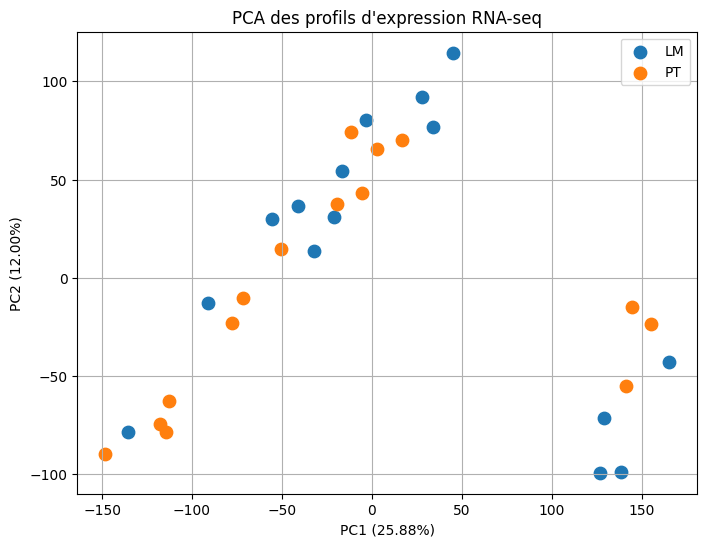

In [33]:
import matplotlib.pyplot as plt

samples = expression_T.index

groups = ['LM' if 'LM' in sample else 'PT' for sample in samples]

plt.figure(figsize=(8,6))

for group in ['LM', 'PT']:
    indices = [i for i, g in enumerate(groups) if g == group]
    
    plt.scatter(
        pca_result[indices,0],
        pca_result[indices,1],
        label=group,
        s=80
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA des profils d'expression RNA-seq")
plt.legend()
plt.grid()
plt.show()

In [34]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=10)

pca_data = pca_full.fit_transform(scaled_expression)

print(pca_data.shape)

(30, 10)


In [35]:
print(pca_data.shape)

(30, 10)


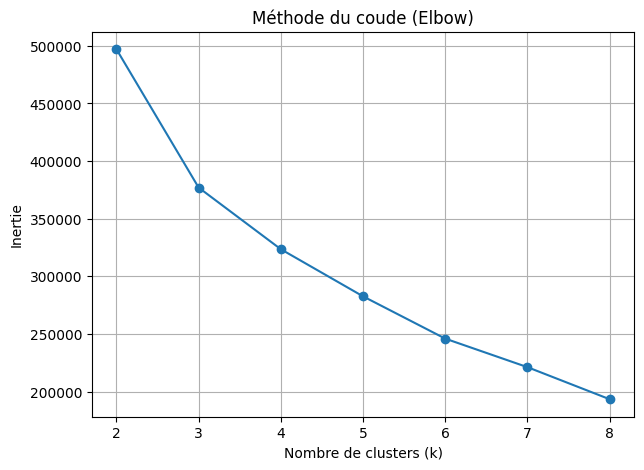

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(2,9)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(pca_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K), inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude (Elbow)")
plt.grid()
plt.show()

In [1]:
import os

print("Dossier actuel :")
print(os.getcwd())

print("\nContenu du dossier data :")
print(os.listdir("../data"))

Dossier actuel :
C:\Users\Dell\Documents\Stage bioinfo\notebooks

Contenu du dossier data :
['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [7]:
import pandas as pd

counts = pd.read_csv("../data/GSE255163_RNAseq_count.csv.gz")

print("Matrice chargée avec succès !")
print("Dimensions :", counts.shape)

Matrice chargée avec succès !
Dimensions : (59953, 32)


In [9]:
# Afficher les premières lignes
counts.head()

,Name,Description,Pt19LM,Pt20LM,Pt15LM,Pt16LM,Pt17LM,Pt01LM,Pt02LM,Pt06LM1,...,Pt17PT,Pt01PT,Pt02PT,Pt06PT,Pt05PT,Pt07PT,Pt08PT1,Pt08PT2,Pt10PT,Pt11PT
0,ENSG00000223972.5_2,DDX11L1,3,19,0,4,2,18,9,2,...,10,2,1,2,5,4,4,2,0,7
1,ENSG00000227232.5_2,WASH7P,1229,475,2469,1662,1789,199,478,292,...,426,277,460,309,460,333,681,599,238,350
2,ENSG00000243485.5_6,MIR1302-2HG,0,2,6,6,10,0,1,0,...,0,2,0,0,0,0,2,0,2,0
3,ENSG00000237613.2_3,FAM138A,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,ENSG00000268020.3_4,OR4G4P,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,4,0,0,0


In [10]:
# Informations sur les colonnes et les types
print(counts.info())

<class 'pandas.DataFrame'>
RangeIndex: 59953 entries, 0 to 59952
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         59953 non-null  str  
 1   Description  59953 non-null  str  
 2   Pt19LM       59953 non-null  int64
 3   Pt20LM       59953 non-null  int64
 4   Pt15LM       59953 non-null  int64
 5   Pt16LM       59953 non-null  int64
 6   Pt17LM       59953 non-null  int64
 7   Pt01LM       59953 non-null  int64
 8   Pt02LM       59953 non-null  int64
 9   Pt06LM1      59953 non-null  int64
 10  Pt06LM2      59953 non-null  int64
 11  Pt05LM1      59953 non-null  int64
 12  Pt05LM2      59953 non-null  int64
 13  Pt07LM       59953 non-null  int64
 14  Pt08LM       59953 non-null  int64
 15  Pt10LM       59953 non-null  int64
 16  Pt11LM       59953 non-null  int64
 17  Pt19PT       59953 non-null  int64
 18  Pt20PT       59953 non-null  int64
 19  Pt18PT       59953 non-null  int64
 20  Pt13PT       5995

In [11]:
# Noms des colonnes
print(counts.columns.tolist())

['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']


In [12]:
print(counts.iloc[:, :5].head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM
0  ENSG00000223972.5_2      DDX11L1       3      19       0
1  ENSG00000227232.5_2       WASH7P    1229     475    2469
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6
3  ENSG00000237613.2_3      FAM138A       1       0       0
4  ENSG00000268020.3_4       OR4G4P       0       0       0


In [13]:
print("Nombre de lignes :", len(counts))
print("Nombre de colonnes :", len(counts.columns))

Nombre de lignes : 59953
Nombre de colonnes : 32


In [14]:
counts.head()

,Name,Description,Pt19LM,Pt20LM,Pt15LM,Pt16LM,Pt17LM,Pt01LM,Pt02LM,Pt06LM1,...,Pt17PT,Pt01PT,Pt02PT,Pt06PT,Pt05PT,Pt07PT,Pt08PT1,Pt08PT2,Pt10PT,Pt11PT
0,ENSG00000223972.5_2,DDX11L1,3,19,0,4,2,18,9,2,...,10,2,1,2,5,4,4,2,0,7
1,ENSG00000227232.5_2,WASH7P,1229,475,2469,1662,1789,199,478,292,...,426,277,460,309,460,333,681,599,238,350
2,ENSG00000243485.5_6,MIR1302-2HG,0,2,6,6,10,0,1,0,...,0,2,0,0,0,0,2,0,2,0
3,ENSG00000237613.2_3,FAM138A,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,ENSG00000268020.3_4,OR4G4P,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,4,0,0,0


In [15]:
print(counts.columns.tolist())

['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']


In [16]:
import GEOparse

gse255163 = GEOparse.get_GEO(
    geo="GSE255163",
    destdir="../data"
)

print("GSE chargé :", gse255163.name)
print("Nombre d'échantillons :", len(gse255163.gsms))

09-Aug-2026 22:32:40 DEBUG utils - Directory ../data already exists. Skipping.
09-Aug-2026 22:32:40 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE255nnn/GSE255163/soft/GSE255163_family.soft.gz to ../data\GSE255163_family.soft.gz
100%|██████████| 3.08k/3.08k [00:02<00:00, 1.45kB/s]
09-Aug-2026 22:32:44 DEBUG downloader - Size validation passed
09-Aug-2026 22:32:44 DEBUG downloader - Moving C:\Users\Dell\AppData\Local\Temp\tmpx6_13mqg to C:\Users\Dell\Documents\Stage bioinfo\data\GSE255163_family.soft.gz
09-Aug-2026 22:32:44 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE255nnn/GSE255163/soft/GSE255163_family.soft.gz
09-Aug-2026 22:32:44 INFO GEOparse - Parsing ../data\GSE255163_family.soft.gz: 
09-Aug-2026 22:32:44 DEBUG GEOparse - DATABASE: GeoMiame
09-Aug-2026 22:32:44 DEBUG GEOparse - SERIES: GSE255163
09-Aug-2026 22:32:44 DEBUG GEOparse - PLATFORM: GPL24676
09-Aug-2026 22:32:44 DEBUG GEOparse - SAMPLE: GSM8065059
09-Aug-202

GSE chargé : GSE255163
Nombre d'échantillons : 30


In [17]:
for gsm_id, gsm in gse255163.gsms.items():
    print("=" * 60)
    print("GSM :", gsm_id)
    
    if "characteristics_ch1" in gsm.metadata:
        for info in gsm.metadata["characteristics_ch1"]:
            print(info)

GSM : GSM8065059
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065060
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065061
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065062
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065063
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065064
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065065
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065066
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065067
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065068
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065069
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065070
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065071
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065072
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065073
tissue:

In [18]:
for gsm_id, gsm in gse255163.gsms.items():
    print("=" * 60)
    print("GSM :", gsm_id)
    
    for key in ["title", "source_name_ch1", "characteristics_ch1"]:
        if key in gsm.metadata:
            print(key, ":", gsm.metadata[key])

GSM : GSM8065059
title : ['RNA-Seq - Pt01LM']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065060
title : ['RNA-Seq - Pt01PT']
source_name_ch1 : ['tumor (primary tumor of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (primary tumor of colorectal cancer)']
GSM : GSM8065061
title : ['RNA-Seq - Pt02LM']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065062
title : ['RNA-Seq - Pt02PT']
source_name_ch1 : ['tumor (primary tumor of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (primary tumor of colorectal cancer)']
GSM : GSM8065063
title : ['RNA-Seq - Pt05LM1']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065064
title : ['RNA-Seq - Pt05

In [19]:
# Création des métadonnées à partir des noms des échantillons

sample_names = counts.columns[2:]

metadata = pd.DataFrame(index=sample_names)

metadata["Condition"] = [
    "Liver_Metastasis" if "LM" in sample else "Primary_Tumor"
    for sample in sample_names
]

metadata.head()

,Condition
Pt19LM,Liver_Metastasis
Pt20LM,Liver_Metastasis
Pt15LM,Liver_Metastasis
Pt16LM,Liver_Metastasis
Pt17LM,Liver_Metastasis


In [20]:
print(metadata["Condition"].value_counts())

Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [21]:
print("Nombre d'échantillons dans la matrice :", len(sample_names))
print("Nombre d'échantillons dans metadata :", len(metadata))

Nombre d'échantillons dans la matrice : 30
Nombre d'échantillons dans metadata : 30


In [22]:
print(metadata)

                Condition
Pt19LM   Liver_Metastasis
Pt20LM   Liver_Metastasis
Pt15LM   Liver_Metastasis
Pt16LM   Liver_Metastasis
Pt17LM   Liver_Metastasis
Pt01LM   Liver_Metastasis
Pt02LM   Liver_Metastasis
Pt06LM1  Liver_Metastasis
Pt06LM2  Liver_Metastasis
Pt05LM1  Liver_Metastasis
Pt05LM2  Liver_Metastasis
Pt07LM   Liver_Metastasis
Pt08LM   Liver_Metastasis
Pt10LM   Liver_Metastasis
Pt11LM   Liver_Metastasis
Pt19PT      Primary_Tumor
Pt20PT      Primary_Tumor
Pt18PT      Primary_Tumor
Pt13PT      Primary_Tumor
Pt15PT      Primary_Tumor
Pt17PT      Primary_Tumor
Pt01PT      Primary_Tumor
Pt02PT      Primary_Tumor
Pt06PT      Primary_Tumor
Pt05PT      Primary_Tumor
Pt07PT      Primary_Tumor
Pt08PT1     Primary_Tumor
Pt08PT2     Primary_Tumor
Pt10PT      Primary_Tumor
Pt11PT      Primary_Tumor


In [23]:
print(metadata["Condition"].value_counts())

Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [24]:
print("Nombre d'échantillons dans la matrice :", len(sample_names))
print("Nombre d'échantillons dans metadata :", len(metadata))

print("\nCorrespondance des noms :")
print(counts.columns[2:].equals(metadata.index))

Nombre d'échantillons dans la matrice : 30
Nombre d'échantillons dans metadata : 30

Correspondance des noms :
True


In [25]:
# Vérifier les types de données des échantillons

print(counts[sample_names].dtypes.value_counts())

int64    30
Name: count, dtype: int64


In [26]:
# Vérifier les valeurs manquantes

missing = counts[sample_names].isna().sum().sum()

print("Nombre total de valeurs manquantes :", missing)

Nombre total de valeurs manquantes : 0


In [27]:
# Vérifier les valeurs négatives

negative_values = (counts[sample_names] < 0).sum().sum()

print("Nombre de valeurs négatives :", negative_values)

Nombre de valeurs négatives : 0


In [28]:
# Vérifier si les comptages sont des nombres entiers

non_integer = (
    counts[sample_names] % 1 != 0
).sum().sum()

print("Nombre de valeurs non entières :", non_integer)

Nombre de valeurs non entières : 0


In [29]:
# Préparation de la matrice de comptages

count_matrix = counts.set_index("Name")[sample_names]

print("Dimensions de la matrice :", count_matrix.shape)
print(count_matrix.head())

Dimensions de la matrice : (59953, 30)
                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000243485.5_6       0       2       6       6      10       0       1   
ENSG00000237613.2_3       1       0       0       0       0       0       0   
ENSG00000268020.3_4       0       0       0       0       0       0       0   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000243485.5_6        0        0        2  ...       0       2       0   
ENSG00000237

In [30]:
# Vérifier les identifiants de gènes dupliqués

print("Nombre total de lignes :", len(count_matrix))
print("Nombre d'identifiants uniques :", count_matrix.index.nunique())
print("Nombre de doublons :", count_matrix.index.duplicated().sum())

Nombre total de lignes : 59953
Nombre d'identifiants uniques : 59953
Nombre de doublons : 0


In [31]:
# Filtrage des gènes faiblement exprimés

min_count = 10
min_samples = 3

keep_genes = (count_matrix >= min_count).sum(axis=1) >= min_samples

count_matrix_filtered = count_matrix[keep_genes]

print("Nombre de gènes avant filtrage :", count_matrix.shape[0])
print("Nombre de gènes après filtrage :", count_matrix_filtered.shape[0])
print("Nombre de gènes supprimés :", 
      count_matrix.shape[0] - count_matrix_filtered.shape[0])

Nombre de gènes avant filtrage : 59953
Nombre de gènes après filtrage : 29182
Nombre de gènes supprimés : 30771


In [32]:
print("Dimensions après filtrage :", count_matrix_filtered.shape)

Dimensions après filtrage : (29182, 30)


In [33]:
print(count_matrix_filtered.head())

                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000238009.6_8       3      15       5      20      18       0       2   
ENSG00000233750.3_4      47      34      25      22      42      18       5   
ENSG00000237683.5      1544     241     420    1004    1117     142      25   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000238009.6_8        4        3        5  ...      10       4       6   
ENSG00000233750.3_4       18        9       14  ...

In [34]:
print(metadata.head())

               Condition
Pt19LM  Liver_Metastasis
Pt20LM  Liver_Metastasis
Pt15LM  Liver_Metastasis
Pt16LM  Liver_Metastasis
Pt17LM  Liver_Metastasis


In [35]:
print("Dimensions après filtrage :", count_matrix_filtered.shape)
print(count_matrix_filtered.head())
print(metadata.head())

Dimensions après filtrage : (29182, 30)
                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000238009.6_8       3      15       5      20      18       0       2   
ENSG00000233750.3_4      47      34      25      22      42      18       5   
ENSG00000237683.5      1544     241     420    1004    1117     142      25   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000238009.6_8        4        3        5  ...      10       4       6   
ENSG0000023